In [1]:
#load all packages
import sys
print(sys.executable)
from __future__ import division

import warnings
warnings.filterwarnings('ignore')

import IPython
print("IPython: ",IPython.__version__)

import csv
print("csv: ",csv.__version__)

import pandas as pd
print("pandas: ",pd.__version__)

import matplotlib
import matplotlib.pyplot as plt
print("matplotlib: ",matplotlib.__version__)

import numpy as np
print("numpy: ",np.__version__)

import sklearn
print("Scikit Learn: ",sklearn.__version__)

import tensorflow as tf
print("tensorflow: ",tf.__version__)

import math
import pylab
import time
import pprint as pp
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import NullFormatter
from IPython.display import Image
import shap
print("shap: ",shap.__version__)
import xgboost as xgb
print("xgboost: ",xgb.__version__)
import statsmodels
print("statsmodels:",statsmodels.__version__)

D:\conda_envs\jupyter_env\python.exe
IPython:  9.8.0
csv:  1.0
pandas:  3.0.2
matplotlib:  3.8.0
numpy:  1.26.4
Scikit Learn:  1.3.2

tensorflow:  2.15.0
shap:  0.44.1
xgboost:  2.0.3
statsmodels: 0.14.1


In [2]:
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_val_predict
from sklearn.pipeline import Pipeline
#from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,classification_report,roc_auc_score,average_precision_score,brier_score_loss,accuracy_score,precision_score,recall_score,f1_score)
from sklearn.calibration import CalibratedClassifierCV,calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier


In [3]:
#set display options for pandas data framework
pd.options.display.max_columns=50
pd.options.display.max_rows=300

#ini_dataset is the as-is load of the sfe data without any preprocess
ini_dataset=pd.read_csv('Final SFE Data.csv',delimiter=',',index_col=None,header=0)
colheaders=list(ini_dataset.columns.values)

print(colheaders)
print("\n")
print(ini_dataset.head(2))

['C', 'N', 'P', 'S', 'V', 'Ni', 'Nb', 'Al', 'Ti', 'Fe', 'Hf', 'Mo', 'Mn', 'Co', 'Si', 'Cr', 'Cu', 'DOI', 'url', 'SFE', 'Error', 'title', 'Author', 'temperature', 'experiment_type']


       C      N      P      S    V    Ni   Nb   Al   Ti      Fe   Hf   Mo  \
0  0.004  0.003  0.025  0.001  0.0  15.6  0.0  0.0  0.0  64.317  0.0  2.5   
1  0.020  0.009  0.022  0.001  0.0  15.6  0.0  0.0  0.0  64.188  0.0  2.5   

     Mn   Co    Si    Cr   Cu                        DOI  \
0  0.03  0.0  0.02  17.5  0.0  10.1007/s11661-013-1943-0   
1  0.03  0.0  0.03  17.6  0.0  10.1007/s11661-013-1943-0   

                                                 url   SFE     Error  \
0  http://link.springer.com/article/10.1007/s1166...  51.6  0.014341   
1  http://link.springer.com/article/10.1007/s1166...  54.6  0.023810   

                                               title            Author  \
0  The Effect of Chemical Composition and Heat Tr...  Yonezawa, Toshio   
1  The Effect of Chemical Composition a

Dataprocessing
selecting measurements only on room temperature

In [4]:
print("There are total %d observations in the dataset" %len(ini_dataset))
print("There are total %d observations in the dataset that are room temperature measurements" %len(ini_dataset[(ini_dataset.temperature>290)&(ini_dataset.temperature<310)]))
#subset with room temperature measuremnets
ini_dataset_1=ini_dataset[(ini_dataset.temperature>290)&(ini_dataset.temperature<310)]
print("There are total %d observations in the room temp dataset"%len(ini_dataset_1))

There are total 473 observations in the dataset
There are total 426 observations in the dataset that are room temperature measurements
There are total 426 observations in the room temp dataset


selecting measurements from only experiments

In [5]:
#displaying different experiment types in our dataset
print(ini_dataset_1.experiment_type.unique())

<StringArray>
[            'TEM - WBDF',                    'XRD',                    'TEM',
 'Thermodynamic Modeling',        'Synchrotron XRD',               'TEM-WBDF',
    'Neutron Diffraction',      'Literature Review',      'Literature review']
Length: 9, dtype: str


In [6]:
len(ini_dataset_1[ini_dataset_1.experiment_type !='Thermodynamic Modeling'])

387

In [7]:
# ini_dataset_2 is another subset with only experimental values
ini_dataset_2= ini_dataset_1[ini_dataset_1.experiment_type!='Thermodynamic Modeling']
print(len(ini_dataset_2),"\n")

#dropping columns url and doi
print(ini_dataset_2.columns.values)
print(len(ini_dataset_2.columns.values))
print(ini_dataset_2.columns[[17,18]],"\n")
ini_dataset_2=ini_dataset_2.drop(['DOI','url'],axis=1)
print(ini_dataset_2.columns.values)
print(len(ini_dataset_2.columns.values))

387 

<StringArray>
[              'C',               'N',               'P',               'S',
               'V',              'Ni',              'Nb',              'Al',
              'Ti',              'Fe',              'Hf',              'Mo',
              'Mn',              'Co',              'Si',              'Cr',
              'Cu',             'DOI',             'url',             'SFE',
           'Error',           'title',          'Author',     'temperature',
 'experiment_type']
Length: 25, dtype: str
25
Index(['DOI', 'url'], dtype='str') 

<StringArray>
[              'C',               'N',               'P',               'S',
               'V',              'Ni',              'Nb',              'Al',
              'Ti',              'Fe',              'Hf',              'Mo',
              'Mn',              'Co',              'Si',              'Cr',
              'Cu',             'SFE',           'Error',           'title',
          'Author',     'temperature

In [8]:
#ini_dataset_3 is next subset with only ferrous alloys
print(len(ini_dataset_2))
print(len(ini_dataset_2[ini_dataset_2.Author!='Unfried-Silgado, Jimy']))
ini_dataset_3=ini_dataset_2[ini_dataset.Author!='Unfried-Silgado, Jimy']
print(len(ini_dataset_3))

387
379
379


selecting predictor variables

In [9]:
colheaders_2=['C','N','P','S','V','Ni','Nb','Mn','Al','Ti','Fe','Hf','Mo','Co','Si','Cr','Cu']
for item in colheaders_2:
    print (item,len(ini_dataset_3[ini_dataset_3[item]>0]),len(ini_dataset_3[ini_dataset_3[item]>0.05]))

C 339 98
N 248 85
P 170 7
S 170 1
V 0 0
Ni 300 300
Nb 2 2
Mn 305 217
Al 34 27
Ti 0 0
Fe 379 379
Hf 0 0
Mo 168 133
Co 3 3
Si 240 120
Cr 332 332
Cu 6 6


In [10]:
#check measurements with (Nb, Co, Cu)
ini_dataset_3_1=ini_dataset_3[(ini_dataset_3.Nb>0.05)|(ini_dataset_3.Co>0.05)|(ini_dataset_3.Cu>0.05)]
ini_dataset_3_1.iloc[:,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,]]

,C,N,P,S,V,Ni,Nb,Al,Ti,Fe,Hf,Mo,Mn,Co,Si,Cr,Cu,SFE,Error,Author
117,0.047,0.205,0.00,0.000,0.0,3.71,0.00,0.0,0.0,71.218,0.0,0.05,6.74,0.00,0.32,17.48,0.23,13.20,0.000000,"Barman, H."
132,0.047,0.205,0.00,0.000,0.0,3.71,0.00,0.0,0.0,71.218,0.0,0.05,6.74,0.00,0.32,17.48,0.23,15.84,0.000000,"Barman, H."
237,0.041,0.054,0.00,0.000,0.0,8.10,0.00,0.0,0.0,70.875,0.0,0.32,1.71,0.00,0.33,18.20,0.37,17.80,0.067416,"Talonen, J."
238,0.019,0.094,0.00,0.000,0.0,6.60,0.00,0.0,0.0,73.237,0.0,0.14,1.61,0.00,0.48,17.60,0.22,12.80,0.117188,"Talonen, J."
239,0.017,0.145,0.00,0.000,0.0,6.60,0.00,0.0,0.0,73.698,0.0,0.15,1.34,0.00,0.51,17.40,0.14,14.70,0.054422,"Talonen, J."
256,0.023,0.000,0.00,0.000,0.0,8.59,0.00,0.0,0.0,66.667,0.0,0.00,0.15,6.42,0.19,17.96,0.00,11.50,0.000000,"Dulieu, D."
257,0.115,0.000,0.00,0.000,0.0,10.04,0.00,0.0,0.0,66.525,0.0,0.00,0.22,0.00,0.10,17.80,5.20,63.25,0.090900,"Dulieu, D."
335,0.006,0.007,0.01,0.014,0.0,15.00,0.00,0.0,0.0,49.420,0.0,0.00,0.04,20.20,0.00,15.30,0.00,27.60,0.000000,"Silcock, J.M."
339,0.000,0.000,0.00,0.000,0.0,10.10,0.00,0.0,0.0,64.350,0.0,0.00,0.00,9.55,0.00,16.00,0.00,18.40,0.000000,"Silcock, J.M."
351,0.014,0.004,0.00,0.000,0.0,20.00,1.00,0.0,0.0,58.982,0.0,0.00,0.00,0.00,0.00,20.00,0.00,17.25,0.000000,"Douglass, D.L."


In [11]:
#ini_dataset_4 is the next subset with the chosen 9 elements with enough datapoints
ini_dataset_4=ini_dataset_3[(ini_dataset_3.Nb<1)&(ini_dataset_3.Co<1)&(ini_dataset_3.Cu<1)]
len(ini_dataset_4)

374

In [12]:
ini_dataset_4=ini_dataset_4.drop(['P','S','V','Nb','Co','Ti','Hf','Cu'],axis=1)
print(ini_dataset_4.columns.values)
print(len(ini_dataset_4.columns.values))


<StringArray>
[              'C',               'N',              'Ni',              'Al',
              'Fe',              'Mo',              'Mn',              'Si',
              'Cr',             'SFE',           'Error',           'title',
          'Author',     'temperature', 'experiment_type']
Length: 15, dtype: str
15


In [13]:
index=range(1,len(ini_dataset_4)+1)
#ini_dataset_5 is another dataframe to make some format changes and let ini_dataset_4 ba as-is
ini_dataset_5=ini_dataset_4
print(len(ini_dataset_5))
ini_dataset_5.insert(0,'sno',index)

374


In [14]:
ini_dataset_5=ini_dataset_5.set_index(['sno'])
#display the final data framework
ini_dataset_5.head()

,C,N,Ni,Al,Fe,Mo,Mn,Si,Cr,SFE,Error,title,Author,temperature,experiment_type
sno,,,,,,,,,,,,,,,
1,0.004,0.003,15.6,0.0,64.317,2.5,0.03,0.02,17.5,51.6,0.014341,The Effect of Chemical Composition and Heat Tr...,"Yonezawa, Toshio",300,TEM - WBDF
2,0.020,0.009,15.6,0.0,64.188,2.5,0.03,0.03,17.6,54.6,0.023810,The Effect of Chemical Composition and Heat Tr...,"Yonezawa, Toshio",300,TEM - WBDF
3,0.020,0.002,14.0,0.0,66.409,2.4,0.03,0.01,17.1,50.3,0.023062,The Effect of Chemical Composition and Heat Tr...,"Yonezawa, Toshio",300,TEM - WBDF
4,0.005,0.001,15.6,0.0,63.866,2.6,0.19,0.01,17.7,52.8,0.012879,The Effect of Chemical Composition and Heat Tr...,"Yonezawa, Toshio",300,TEM - WBDF
5,0.016,0.008,10.8,0.0,68.899,0.3,0.85,0.10,19.0,35.0,0.023429,The Effect of Chemical Composition and Heat Tr...,"Yonezawa, Toshio",300,TEM - WBDF


In [15]:
ini_array=ini_dataset_5.reset_index().values
print(ini_array.shape)
print(ini_array[0,:])

(374, 16)
[1 0.004 0.003 15.6 0.0 64.317 2.5 0.03 0.02 17.5 51.6 0.014341085
 'The Effect of Chemical Composition and Heat Treatment Conditions on Stacking Fault Energy for Fe-Cr-Ni Austenitic Stainless Steel'
 'Yonezawa, Toshio' 300 'TEM - WBDF']


In [16]:
#subsetting the array to include only numerical values needed for analysis
SFEdata=ini_array[:,0:12]
print(SFEdata[0,:])
SFEdata=np.array(SFEdata, dtype='float')

#constructing a band of SFE values based on error bars (SFE low and SFE high)
low=SFEdata[:,10]*(1-SFEdata[:,11])
high=SFEdata[:,10]*(1+SFEdata[:,11])
lowhigh=np.column_stack((low,high))

#adding the SFE band columns to the array
SFEdata=np.column_stack((SFEdata,lowhigh))
print(SFEdata.shape)
print(SFEdata[0,:])

[1 0.004 0.003 15.6 0.0 64.317 2.5 0.03 0.02 17.5 51.6 0.014341085]
(374, 14)
[1.0000000e+00 4.0000000e-03 3.0000000e-03 1.5600000e+01 0.0000000e+00
 6.4317000e+01 2.5000000e+00 3.0000000e-02 2.0000000e-02 1.7500000e+01
 5.1600000e+01 1.4341085e-02 5.0860000e+01 5.2340000e+01]


In [17]:
#determine class based on sfe values
SFEclass=np.zeros(SFEdata.shape[0])

SFEclass[SFEdata[:,10]<39]=0
SFEclass[(SFEdata[:,10]>=39)]=1

#check number of entries for each class
print((SFEclass==0).sum())
print((SFEclass==1).sum())
#check if only the needed classes there
print((SFEclass==0).sum()+(SFEclass==1).sum())
print(SFEclass.shape)
print(SFEdata.shape)

201
173
374
(374,)
(374, 14)


In [18]:
#data preprocessing
Elements=SFEdata[:,1:10]
print(Elements.shape)
print('Elementlist:',ini_dataset_5.columns.values[0:9])
def arraynorm(array, axis):
    minaxis=np.nanmin(array,axis)
    maxaxis=np.nanmax(array,axis)
    diffaxis=maxaxis-minaxis
    output=np.true_divide(array-minaxis,diffaxis)
    return output
def arraystandardize(array,axis):
    meanaxis=np.mean(array,axis)
    stdaxis=np.std(array,axis)
    output=np.true_divide(array-meanaxis,stdaxis)
    return output
NormElements=arraynorm(Elements[:,:],0) #Perform normalization on element data
print(NormElements.shape)
StdElements=arraystandardize(Elements[:,:],0)#Standardize element data
SFEclassint=np.array(SFEclass,dtype='int')#Convert SFE category to integer type

(374, 9)
Elementlist: <StringArray>
['C', 'N', 'Ni', 'Al', 'Fe', 'Mo', 'Mn', 'Si', 'Cr']
Length: 9, dtype: str
(374, 9)


#80:20::train:test sets
#Build models on the training set, evaluate performance on unseen test sets, and select the model with the best generalization ability

In [19]:
# First check the data distribution (key!)
def check_data_distribution(y):
    dist = pd.Series(y).value_counts(normalize=True) * 100
    print("=== Category distribution ===")
    print(dist)
    return dist

# Check data distribution (must be done first!)
check_data_distribution(SFEclass)

print("=== Split the training+validation set&independent testing set ===")
# Maintain category distribution (strategize) during splitting, fix random seeds to ensure reproducibility
X_train_val,X_test,y_train_val,y_test=train_test_split(NormElements,SFEclass,test_size=0.2,stratify=SFEclass,random_state=42) 
feature_names=['C','N','Ni','Al','Fe','Mo','Mn','Si','Cr']

=== Category distribution ===
0.0    53.743316
1.0    46.256684
Name: proportion, dtype: float64
=== Split the training+validation set&independent testing set ===


In [20]:
#helper:bootstrap prediction "interval"(uncertainty band for (p))
def bootstrap_proba_intervals(fit_predict_proba_fn,X_train,y_train,X_eval,B=200,alpha=0.05,random_state=42):
    rng = np.random.default_rng(random_state)
    X_train=np.asarray(X_train);y_train=np.asarray(y_train);X_eval=np.asarray(X_eval)
    n=X_train.shape[0]
    probs=[]

    for _ in range(B):
        idx=rng.integers(0,n,size=n)
        #est=clone(pipeline)
        #est.fit(X_train[idx],y_train[idx])
        #probs.append(est.predict_proba(X_eval)[:,1])
        probs.append(fit_predict_proba_fn(X_train[idx],y_train[idx],X_eval))

    probs=np.vstack(probs)
    mid=np.median(probs,axis=0)
    lo=np.quantile(probs,alpha/2,axis=0)
    hi=np.quantile(probs,1-alpha/2,axis=0)
    return mid,lo,hi

In [21]:
#helper plots
def plot_confusion(y_true,y_pred,title,savepath=None):
    cm=confusion_matrix(y_true,y_pred)
    disp=ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax=plt.subplots(figsize=(4,4),dpi=150)
    disp.plot(ax=ax,colorbar=False,values_format="d")
    ax.set_title(title)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath,bbox_inches="tight")
    return fig

def plot_calibration(y_true,proba,title,savepath=None,n_bins=10):
    prob_true,prob_pred=calibration_curve(y_true,proba,n_bins=n_bins,strategy="uniform")
    fig,ax=plt.subplots(figsize=(4.5,4),dpi=150)
    ax.plot([0,1],[0,1],"--",color="gray",label="Perfect")
    ax.plot(prob_pred,prob_true,marker="o",label="Model")
    ax.set_xlabel("Mean predicted probability")
    ax.set_label("Fraction of positives")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath,bbox_inches="tight")
    return fig

def plot_prediction_interval(proba_mid,proba_lo,proba_hi,title,savepath,y_true=None):
    #sort by median probability for clean band plot
    order = np.argsort(proba_mid)
    x=np.arange(len(proba_mid))

    fig, ax=plt.subplots(figsize=(6,4),dpi=150)
    ax.fill_between(x,proba_lo[order],proba_hi[order],alpha=0.25,label="Bootstrap interval")
    ax.plot(x,mid[order],linewidth=1.5,label="Median p")
    if y_true is not None:
        ax.scatter(x,np.asarray(y_true)[order],s=10,alpha=0.4,label="y(0/1)")
    ax.set_ylim(-0.05,1.05)
    ax.set_xlabel("Test samples (sorted by p)")
    ax.set_ylabel("Predicted probability")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(savepath,bbox_inches="tight")
    return fig


🔍 待评估模型总数: 6
🔍 模型名称列表: ['SVM', 'ANN', 'RF', 'GB', 'XGB', 'ES']
🔄 正在处理模型: SVM
🔄 正在处理模型: ANN
🔄 正在处理模型: RF
🔄 正在处理模型: GB
🔄 正在处理模型: XGB
🔄 正在处理模型: ES
📊 最终收集到的结果行数: 6
model  accuracy  roc_auc   pr_auc    brier  precision   recall       f1
  XGB  0.933333 0.936071 0.931947 0.072809   0.916667 0.942857 0.929577
   GB  0.906667 0.934286 0.927715 0.082858   0.888889 0.914286 0.901408
   ES  0.906667 0.935000 0.913515 0.080930   0.888889 0.914286 0.901408
  ANN  0.880000 0.941429 0.940175 0.093926   0.882353 0.857143 0.869565
  SVM  0.866667 0.946429 0.931958 0.103232   0.931034 0.771429 0.843750
   RF  0.866667 0.922857 0.895177 0.101264   0.837838 0.885714 0.861111


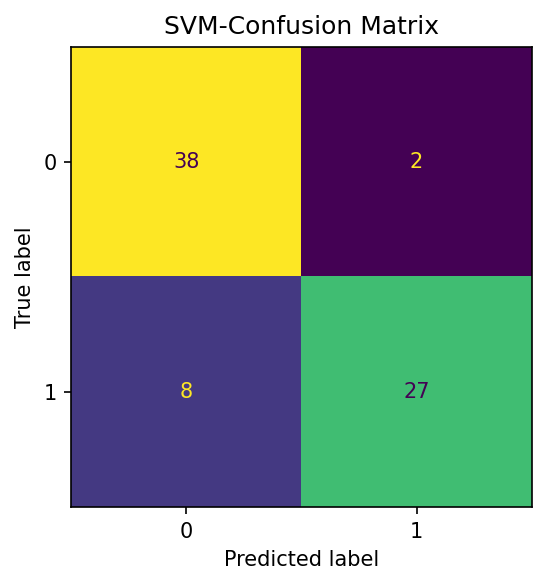

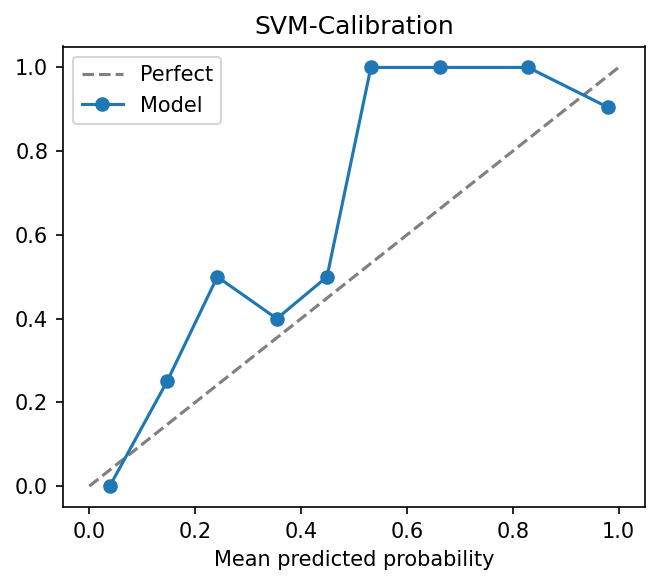

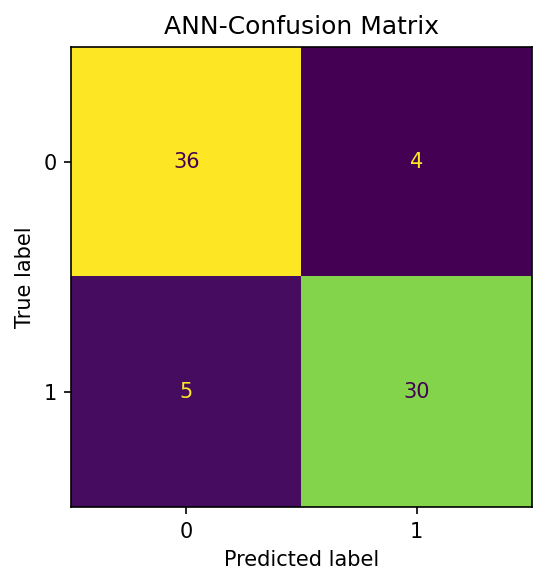

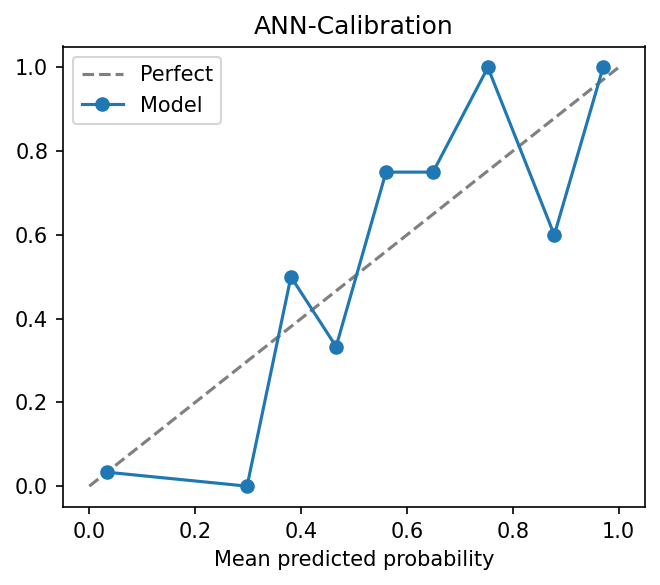

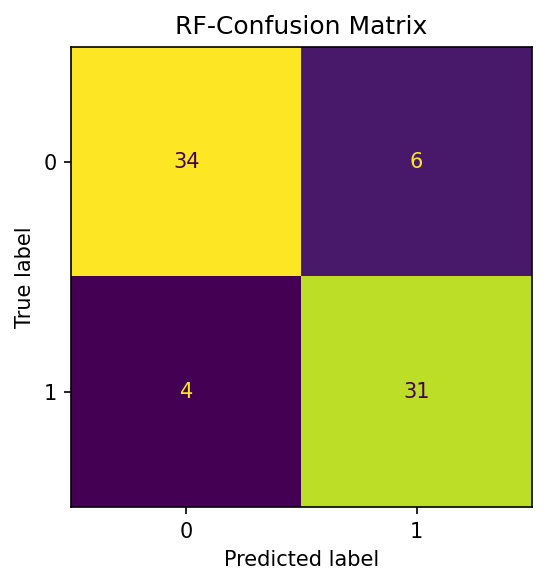

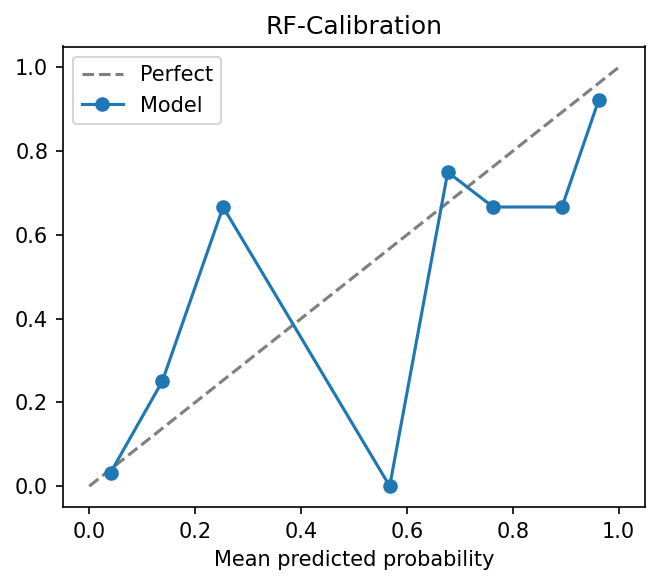

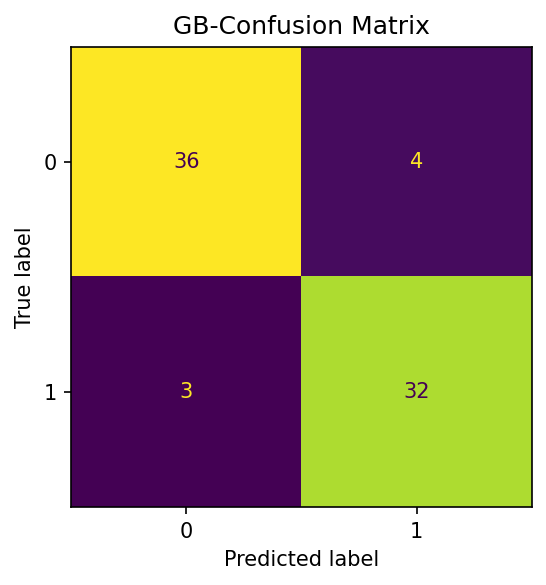

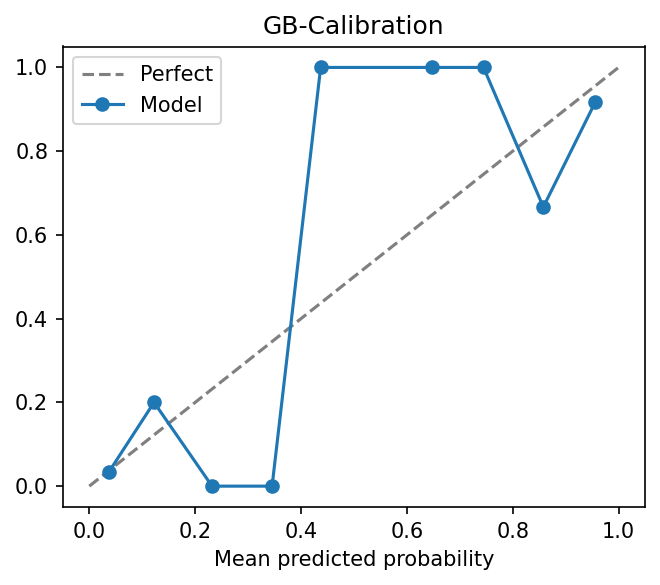

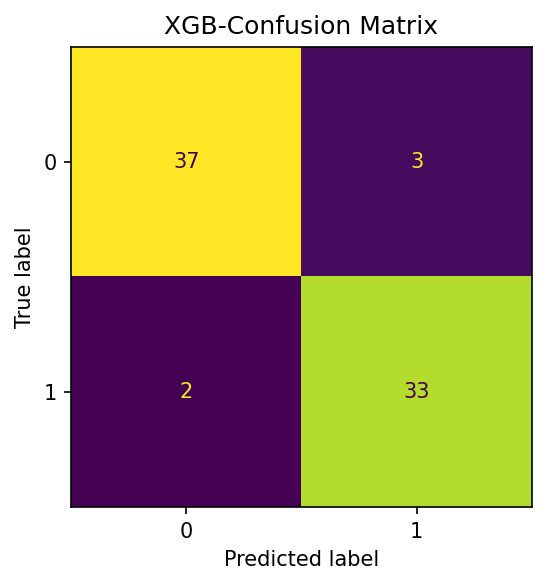

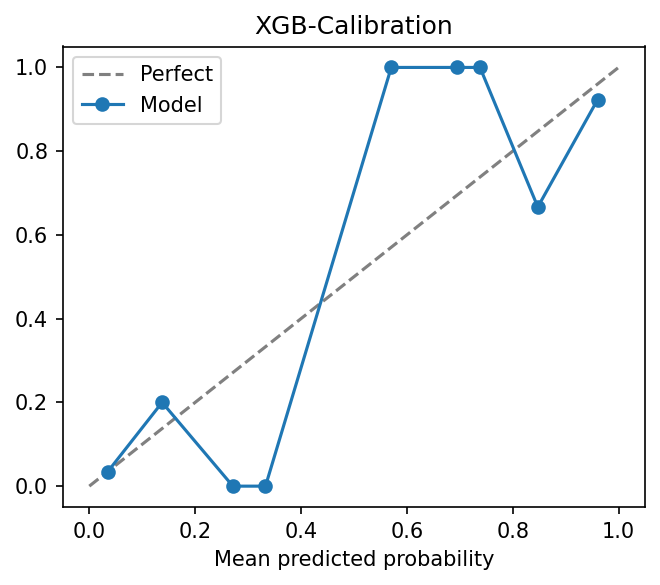

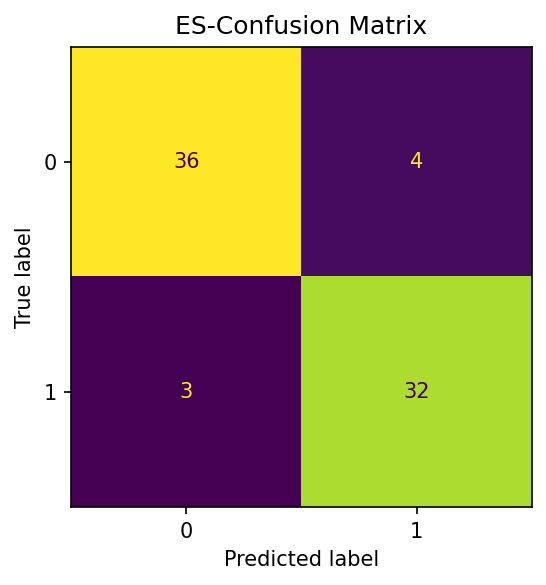

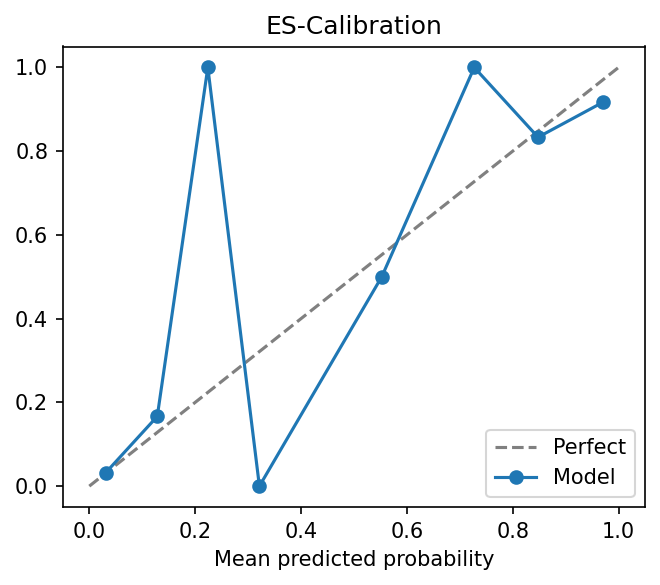

In [38]:

models={
    "SVM":SVC(kernel="rbf",C=1.0,gamma="scale",probability=True,random_state=42),
    "ANN":MLPClassifier(hidden_layer_sizes=(64,32),max_iter=500,random_state=42),
    "RF":RandomForestClassifier(n_estimators=500,random_state=42),
    "GB":GradientBoostingClassifier(random_state=42),
    "XGB":XGBClassifier(n_estimator=500,max_depth=4,learning_rate=0.05,subsample=0.9,colsample_bytree=0.9,eval_metrics="logloss",random_state=42),
}
preprocess=StandardScaler()
stack=StackingClassifier(
    estimators=[(k,Pipeline([("pre",preprocess),("clf",v)]))for k,v in models.items()],
    final_estimator=LogisticRegression(max_iter=2000),
    stack_method="predict_proba",
    passthrough=False
)
all_models={**models,"ES":stack}

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

rows=[]
artifacts={}

print(f"🔍 待评估模型总数: {len(all_models)}")
print(f"🔍 模型名称列表: {list(all_models.keys())}")

for name, clf in all_models.items():
    print(f"🔄 正在处理模型: {name}")
    if name !="stack":
        pipe=Pipeline([("pre",preprocess),("clf",clf)])
    else:
        pipe=clf
    #Calibrated on training via CV (fits calibrator without using X_test)
    calibrated=CalibratedClassifierCV(pipe,method="isotonic",cv=cv)
    calibrated.fit(X_train_val,y_train_val)
    test_proba=calibrated.predict_proba(X_test)[:,1]
    test_pred=(test_proba>=0.5).astype(int)
    rows.append({
        "model":name,
        "accuracy":accuracy_score(y_test,test_pred),
        "roc_auc":roc_auc_score(y_test,test_proba),
        "pr_auc":average_precision_score(y_test,test_proba),
        "brier":brier_score_loss(y_test,test_proba),
        "precision":precision_score(y_test,test_pred,zero_division=0),
        "recall":recall_score(y_test,test_pred,zero_division=0),
        "f1":f1_score(y_test,test_pred,zero_division=0)
        })
    artifacts[name]={"calibrated":calibrated,"proba":test_proba,"pred":test_pred,"pipe":pipe}

    plot_confusion(y_test,test_pred,f"{name}-Confusion Matrix",savepath=f"{name}_confusion.tiff")
    plot_calibration(y_test,test_proba,f"{name}-Calibration",savepath=f"{name}_calibration.tiff")
    #def fit_predict_proba_fn(Xtr,ytr,Xev):
        #est=pipe
        #est=clone(est)
        #est.fit(Xtr,ytr)
        #return est.predict_proba(Xev)[:,1]
    #mid,lo,hi=bootstrap_proba_intervals(fit_predict_proba_fn,X_train_val,y_train_val,X_test,B=200,alpha=0.05,random_state=42)
    #plot_prediction_interval(mid,lo,hi,title=f"{name}-p prediction interval (bootstrap)",savepath=f"{name}_pred_interval.tiff")
    
print(f"📊 最终收集到的结果行数: {len(rows)}")
results_df=pd.DataFrame(rows).sort_values("accuracy",ascending=False)
print(results_df.to_string(index=False))
results_df.to_csv("model_results.csv",index=False)

#out-of-fold probabilities for calibration assessment(no test leakage)
oof_proba = cross_val_predict(pipe,X_train_val,y_train_val,cv=cv,method="predict_proba")[:,1]
#Fit base model on full training set
pipe.fit(X_train_val,y_train_val)

In [35]:
best_name=results_df.iloc[0]["model"]
print(f"\nBest model by accuracy:{best_name}")
best=artifacts[best_name]
best_pipe=best["pipe"]   #uncalibrated pipeline/stack
best_cal=best["calibrated"]  #calibrated wrapper (already fitted)


Best model by accuracy:XGB


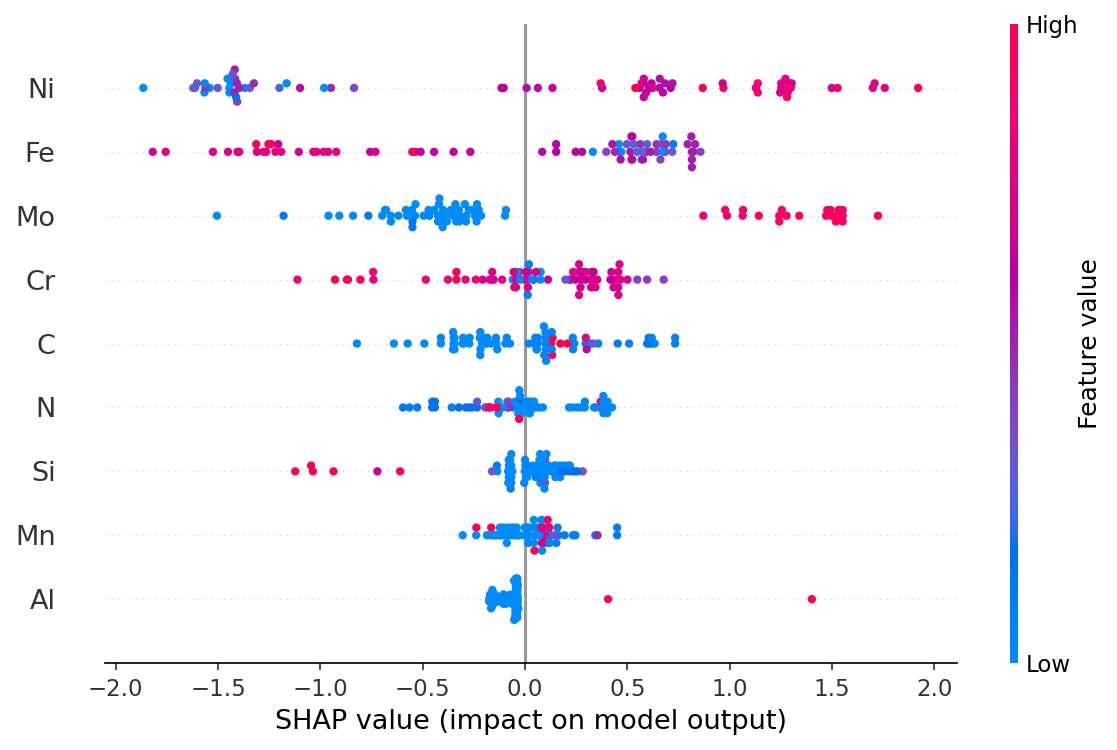

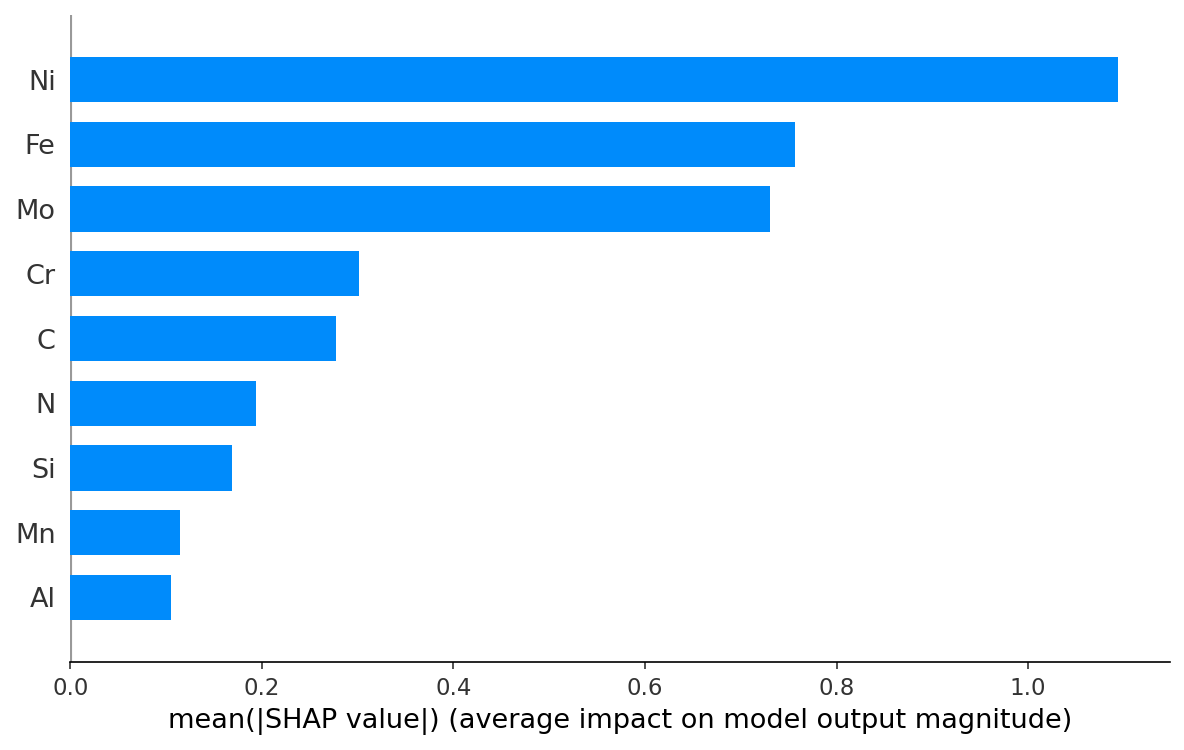

In [36]:
#Fit the pipe model once on full train for SHAP (SHAP needs a fitted underlying estimator)
best_pipe_fitted=clone(best_pipe).fit(X_train_val,y_train_val)
#if best is a pipeline:explain the final estimator with transformed X
if isinstance(best_pipe_fitted,Pipeline):
    X_explain=best_pipe_fitted.named_steps["pre"].transform(X_test)
    model_for_shap=best_pipe_fitted.named_steps["clf"]
    fnames=feature_names
else:
    X_explain=X_test
    model_for_shap=base_pipe_fitted
    fnames=feature_names
# Tree models(XGB/RF/GB) are fast with TreeExplainer; fallback to generic Explainer otherwise
is_tree_like=best_name in ["XGB","RF","GB"] or (best_name == "stack")
if is_tree_like and hasattr(model_for_shap,"get_booster"):
    explainer = shap.TreeExplainer(model_for_shap)
    shap_values=explainer.shap_values(X_explain)
elif is_tree_like:
    #RF/GB: TreeExplainer usually works
    explainer = shap.TreeExplainer(model_for_shap)
    shap_values=explainer.shap_values(X_explain)
else:
    RANDOM_STATE=42
    bg=X_explain[np.random.default_rng(RANDOM_STATE).choice(X_explain.shape[0],size=min(200,X_explain.shape[0]),replace=False)]
    explainer=shap.Explain(model_for_shap,bg)
    shap_values=explainer(X_explain).values #ndarray

plt.figure(dpi=150)
shap.summary_plot(shap_values,X_explain,feature_names=fnames,show=False)
plt.tight_layout()
plt.savefig(f"{best_name}_shap_beeswarm.tiff",bbox_inches="tight")

plt.figure(dpi=150)
shap.summary_plot(shap_values,X_explain,feature_names=fnames,plot_type="bar",show=False)
plt.tight_layout()
plt.savefig(f"{best_name}_shap_bar.tiff",bbox_inches="tight")



Top 15 Features by mean permutation importance:
feature  perm_importance_mean  perm_importance_var
     Ni              0.112190         9.210744e-04
     Mo              0.032190         5.447549e-04
     Fe              0.020405         2.129727e-04
      N              0.009381         4.256627e-05
      C              0.007405         2.559758e-05
     Si             -0.000595         1.837028e-05
     Al             -0.001119         3.407225e-07
     Mn             -0.004095         3.410744e-06
     Cr             -0.004262         6.229709e-05


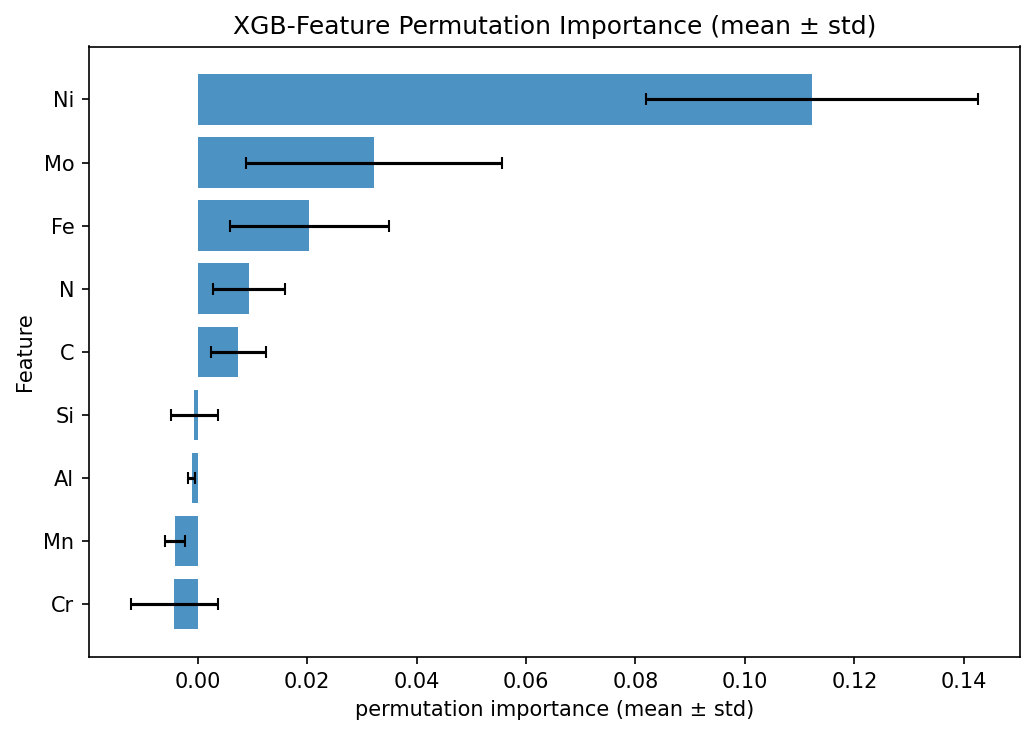

In [37]:
#Variance of feature imporatnce (no retraining):permutation importance variance across repeats
#Use fitted base model; compute permutation importance on test set ,repeats give a variance estimate
r= permutation_importance(best_pipe_fitted,X_test,y_test,scoring="roc_auc",n_repeats=30,random_state=42)
imp_mean=r.importances_mean
imp_var=r.importances.var(axis=1,ddof=1)#variance across repeats per feature

imp_df=pd.DataFrame({"feature":fnames,"perm_importance_mean":imp_mean,"perm_importance_var":imp_var}).sort_values("perm_importance_mean",ascending=False)
imp_df.to_csv(f"{best_name}_perm_importance_variance.csv",index=False)
print("\nTop 15 Features by mean permutation importance:")
print(imp_df.head(15).to_string(index=False))

top_k=20
plot_df=imp_df.head(top_k).iloc[::-1]

plt.figure(figsize=(7,5),dpi=150)
plt.barh(y=plot_df["feature"],width=plot_df["perm_importance_mean"],
         xerr=plot_df["perm_importance_var"]**0.5,
         capsize=3,
         color="#1f77b4",
         alpha=0.8)
plt.xlabel("permutation importance (mean ± std)")
plt.ylabel("Feature")
plt.title(f"{best_name}-Feature Permutation Importance (mean ± std)")
plt.tight_layout()
plt.savefig(f"{best_name}_feature_importance_mean_variance.tiff",bbox_inches="tight")
plt.show()

In [23]:
#1) Metric functions
def metrics_from_proba(y_true,proba,thr=0.5):
    pred=(proba >=thr).astype(int)
    return {
        "accuracy":accuracy_score(y_true,pred),
        "roc_auc":roc_auc_score(y_true,proba),
        "pr_auc":average_precision_score(y_true,proba),
        "f1":f1_score(y_true,pred,zero_division=0),
        "brier":brier_score_loss(y_true,proba),
        "pred":pred
    }

In [24]:
#2)Boostrap CI for one model
def bootstrap_ci_metrics(y_true,proba,B=2000,alpha=0.05,random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    stats ={"accuracy":[],"roc_auc":[],"pr_auc":[],"f1":[],"brier":[]}

    for _ in range(B):
        idx = rng.integers(0,n,size=n)
        yb = y_true[idx]
        pb = proba[idx]

        #skip degenerate AUC bootstrap samples (all one class)
        if len(np.unique(yb)) < 2:
            continue

        m = metrics_from_proba(yb,pb)
        for k in stats:
            stats[k].append(m[k])
    out = {}
    for k, vals in stats.items():
        vals = np.array(vals)
        out[k] ={
            "mean":float(np.mean(vals)),
            "ci_low":float(np.quantile(vals,alpha/2)),
            "ci_high":float(np.quantile(vals,1-alpha/2))
        }
    return out

In [25]:
#3) Permutation_pvalue_auc(model vs random labels)
def permutation_pvalue_auc(y_true,proba,n_perm=5000,random_state=42):
    rng = np.random.default_rng(random_state)
    obs = roc_auc_score(y_true,proba)
    null = np.empty(n_perm)

    for i in range(n_perm):
        yp = rng.permutation(y_true)
        if len(np.unique(yp)) < 2:
            null[i] = 0.5
        else:
            null[i] = roc_auc_score(yp,proba)
    p = (np.sum(null >= obs)+1)/(n_perm+1)
    return obs,p
    

In [26]:
#4) Pairwise p-value+effect size (best vs other)
def paired_bootstrap_delta_auc(y_true,proba_a,proba_b,B=5000,random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    deltas = []

    for _ in range(B):
        idx = rng.integers(0,n,size=n)
        yb = y_true[idx]
        if len(np.unique(yb)) < 2:
            continue
        da = roc_auc_score(yb, proba_a[idx])-roc_auc_score(yb, proba_b[idx])
        deltas.append(da)
    deltas = np.array(deltas)
    ci = (np.quantile(deltas,0.025),np.quantile(deltas,0.975))
    #two-sided p-value from bootstrap sign
    p = 2 * min(np.mean(deltas <=0),np.mean(deltas >=0))
    return float(np.mean(deltas)),(float(ci[0]),float(ci[1])),float(p)
    

In [27]:
#5) Effect size for accuracy difference: Cohen's h
def cohens_h(p1,p2):
    p1 = np.clip(p1, 1e-9, 1-1e-9)
    p2 = np.clip(p2, 1e-9, 1-1e-9)
    return 2 * (np.arcsin(np.sqrt(p1))-np.arcsin(np.sqrt(p2)))

In [28]:
from scipy.stats import binomtest
def accuracy_pvalue_binom(y_true,y_pred,p0):
    k = int(np.sum(y_true == y_pred))
    n = len(y_true)
    p = binomtest(k=k, n=n, p=p0, alternative="greater").pvalue
    return k/n,float(p),k,n

In [29]:
from statsmodels.stats.contingency_tables import mcnemar
def mcnemar_pvalue(y_true, pred_a, pred_b):
    a_correct = (pred_a == y_true)
    b_correct = (pred_b == y_true)
    # contingency on disagreement
    b = int(np.sum(a_correct & (~b_correct))) # A correct, B wrong
    c = int(np.sum((~a_correct) & b_correct)) # A wrong, B correct
    table = [[0, b], [c, 0]]
    result = mcnemar(table, exact=True)
    return float(result.pvalue),b,c

In [30]:
y_test =np.asarray(y_test)
model_names = list(artifacts.keys())
p0_nir =max(np.mean(y_test == 0),np.mean(y_test == 1))
# A) Per-model CI + p-value (vs random-label null on AUC)
report_rows = []
model_preds = {}

for name in model_names:
    proba = np.asarray(artifacts[name]["proba"])
    ci = bootstrap_ci_metrics(y_test,proba,B=2000,alpha=0.05,random_state=42)
    auc_obs,auc_p = permutation_pvalue_auc(y_test,proba,n_perm=3000,random_state=42)
    pred = (proba >= 0.5).astype(int)
    model_preds[name] = pred
    acc_obs, p_acc, k_acc, n_acc = accuracy_pvalue_binom(y_test, pred, p0=p0_nir)
    report_rows.append({
    "model":name,
    "acc":ci["accuracy"]["mean"],
    "acc_ci":f'[{ci["accuracy"]["ci_low"]:.3f},{ci["accuracy"]["ci_high"]:.3f}]',
    "auc":ci["roc_auc"]["mean"],
    "auc_ci":f'[{ci["roc_auc"]["ci_low"]:.3f},{ci["roc_auc"]["ci_high"]:.3f}]',
    "pr_auc":ci["pr_auc"]["mean"],
    "pr_auc_ci":f'[{ci["pr_auc"]["ci_low"]:.3f},{ci["pr_auc"]["ci_high"]:.3f}]',
    "f1":ci["f1"]["mean"],
    "f1_ci":f'[{ci["f1"]["ci_low"]:.3f},{ci["f1"]["ci_high"]:.3f}]',
    "brier":ci["brier"]["mean"],
    "brier_ci":f'[{ci["brier"]["ci_low"]:.3f},{ci["brier"]["ci_high"]:.3f}]',
    "p_auc_vs_random":auc_p,

    "acc_obs":acc_obs,
    "acc_correct_k":k_acc,
    "acc_total_n":n_acc,
    "p_accuracy_vs_nir":p_acc,
    "nir_baseline_p0":p0_nir
    })
report_df = pd.DataFrame(report_rows).sort_values("acc",ascending=False).reset_index(drop=True)
print(report_df.to_string(index=False))
report_df.to_csv("model_ci_pvalues_report.csv",index=False)

model      acc        acc_ci      auc        auc_ci   pr_auc     pr_auc_ci       f1         f1_ci    brier      brier_ci  p_auc_vs_random  acc_obs  acc_correct_k  acc_total_n  p_accuracy_vs_nir  nir_baseline_p0
  XGB 0.932200 [0.867,0.987] 0.934833 [0.860,0.990] 0.930951 [0.845,0.989] 0.927504 [0.857,0.984] 0.073871 [0.031,0.129]         0.000333 0.933333             70           75       3.219114e-14         0.533333
   GB 0.905440 [0.840,0.960] 0.933316 [0.865,0.986] 0.927048 [0.842,0.984] 0.898915 [0.814,0.961] 0.083814 [0.040,0.138]         0.000333 0.906667             68           75       2.945093e-12         0.533333
stack 0.905440 [0.840,0.960] 0.933785 [0.863,0.987] 0.912911 [0.808,0.986] 0.898915 [0.814,0.961] 0.082074 [0.036,0.138]         0.000333 0.906667             68           75       2.945093e-12         0.533333
  ANN 0.878767 [0.800,0.947] 0.940286 [0.882,0.983] 0.939177 [0.873,0.981] 0.866562 [0.769,0.943] 0.094800 [0.056,0.139]         0.000333 0.880000          

In [31]:
#B) Best model vs others:
#report_df_sorted = report_df.sort_values(by="acc", ascending=False)
best_name = report_df.iloc[0]["model"]
best_proba = np.asarray(artifacts[best_name]["proba"])
best_pred = model_preds[best_name]
#best_acc = accuracy_score(y_test,(best_proba >=0.5).astype(int))
best_acc = accuracy_score(y_test,best_pred)

pair_rows =[]
for name in model_names:
    if name == best_name:
        continue
    proba = np.asarray(artifacts[name]["proba"])
    pred = model_preds[name]
    #acc = accuracy_score(y_test,(proba >= 0.5).astype(int))
    acc = accuracy_score(y_test,pred)

    delta_auc, delta_auc_ci,p_delta_auc =paired_bootstrap_delta_auc(y_test,best_proba,proba,B=5000,random_state=42)
    h = cohens_h(best_acc,acc)

    p_mcnemar,b01,b10 = mcnemar_pvalue(y_test,best_pred,pred)

    pair_rows.append({
        "best_model":best_name,
        "compare_to":name,
        "delta_auc":delta_auc,
        "delta_auc_ci":f"[{delta_auc_ci[0]:.3f},{delta_auc_ci[0]:.3f}]",
        "p_delta_auc":p_delta_auc,
        "acc_best":best_acc,
        "acc_other":acc,
        "cohens_h_acc":h,

        "p_mcnemar_acc":p_mcnemar,
        "mcnemar_b01":b01,
        "mcnemar_b10":b10
    })
pair_df = pd.DataFrame(pair_rows).sort_values("p_mcnemar_acc").reset_index(drop=True)
print("\nBest-vs-others comparison:")
print(pair_df.to_string(index=False))
pair_df.to_csv("best_vs_others_effectsize_pvalues.csv",index=False)


Best-vs-others comparison:
best_model compare_to  delta_auc    delta_auc_ci  p_delta_auc  acc_best  acc_other  cohens_h_acc  p_mcnemar_acc  mcnemar_b01  mcnemar_b10
       XGB         RF   0.013186 [-0.016,-0.016]       0.3652  0.933333   0.866667      0.225270        0.06250            5            0
       XGB        SVM  -0.010618 [-0.060,-0.060]       0.6868  0.933333   0.866667      0.225270        0.12500            6            1
       XGB        ANN  -0.005593 [-0.039,-0.039]       0.7408  0.933333   0.880000      0.185168        0.21875            5            1
       XGB         GB   0.001590 [-0.017,-0.017]       0.8844  0.933333   0.906667      0.098623        0.50000            2            0
       XGB      stack   0.000992 [-0.015,-0.015]       0.8344  0.933333   0.906667      0.098623        0.50000            2            0


In [39]:
your_composition = np.array([0.033, 0.3514, 13.953, 0, 57.6706, 2.102, 5.033, 0.342, 20.515])

your_composition_twoarray=your_composition.reshape(1,-1)
print(your_composition_twoarray)

[[3.30000e-02 3.51400e-01 1.39530e+01 0.00000e+00 5.76706e+01 2.10200e+00
  5.03300e+00 3.42000e-01 2.05150e+01]]


In [40]:
#RF Prediction
from sklearn import preprocessing
#min_max_scaler = preprocessing.MinMaxScaler()
#your_compositon_modi=min_max_scaler.transform(your_composition_twoarray)
predicted_classes_rf=best_cal.predict(your_composition_twoarray)
predicted_proba_rf=best_cal.predict_proba(your_composition_twoarray)
print(predicted_classes_rf)
print(predicted_proba_rf)

[1.]
[[0.48061109 0.51938891]]
